# Quality control of the BR-DWGD annual maxima against rain-gauge data

Companion to `controle_qualidade_estacoes.py`, which reads the rain-gauge data used to build the BR-DWGD grid (`pr.npz`, Xavier et al., 2022; 14,170 gauges, 1961–2025, ~1.35 GB, not stored here) and writes the small outputs in `qc/` that this notebook uses:

| File | Content |
|---|---|
| `qc/estacoes_maxima_anual.csv.gz` | annual maximum per gauge (years with ≥ 330 valid days) |
| `qc/anos_excluidos.json` | gauges with monthly totals recorded as daily rainfall, and the municipality-years removed |
| `qc/influencia_estacoes_sinalizadas.csv` | contamination ratio vs. distance to the flagged gauge |
| `qc/pares_grade_estacao.csv` | grid vs. nearest gauge (≤ 10 km, ≥ 30 common years) |
| `qc/tendencias_municipios.csv` | Mann-Kendall and Pettitt per municipality, gauge density within 50 km |
| `qc/estacoes_validas_por_uf_ano.csv` | number of valid gauges per state and year |

Sections: (1) the flagged gauge and the contaminated municipalities, (2) effect of the exclusion on the IDF coefficients, (3) grid vs. gauge, (4) trends and network density, (5) numbers for the paper.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geobr

import calcular_idf_municipios as idf

BASE = Path.cwd()
QC = BASE / 'qc'
FIG = BASE / 'figuras_qc'
FIG.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

qc = json.load(open(QC / 'anos_excluidos.json', encoding='utf-8'))
est_max = pd.read_csv(QC / 'estacoes_maxima_anual.csv.gz', index_col=0)
est_max.columns = est_max.columns.astype(str)
est_meta = pd.read_csv(QC / 'estacoes_meta.csv', dtype={'id': str})
influencia = pd.read_csv(QC / 'influencia_estacoes_sinalizadas.csv', dtype={'codigo_ibge': str})
pares = pd.read_csv(QC / 'pares_grade_estacao.csv', dtype={'codigo_ibge': str, 'estacao': str})
tend = pd.read_csv(QC / 'tendencias_municipios.csv', dtype={'codigo_ibge': str})
contagem = pd.read_csv(QC / 'estacoes_validas_por_uf_ano.csv', index_col=0)
serie = pd.DataFrame(json.load(open(BASE / 'xavier_chuva_maxima_diaria_anual_municipios_1961_2025.json', encoding='utf-8')))
grade = serie.pivot(index='ano', columns='codigo_ibge', values='chuva_max_diaria_mm')
municipios_gdf = geobr.read_municipality(year=2020, simplified=True)
municipios_gdf['codigo_ibge'] = municipios_gdf.code_muni.astype('int64').astype(str)
estados_gdf = geobr.read_state(year=2020, simplified=True)
print('Estações sinalizadas:', [(s['id'], len(s['anos']), s['anos'][0], s['anos'][-1]) for s in qc['estacoes_sinalizadas']])
print('Municípios com anos excluídos:', len(qc['municipios']))

Estações sinalizadas: [('1166000', 37, 1961, 1998)]
Municípios com anos excluídos: 61


## 1. Gauge 1166000 and the contaminated municipalities

In [2]:
s = qc['estacoes_sinalizadas'][0]
ruins = s['anos']
print(f"Estação {s['id']} ({s['lat']:.3f}, {s['lon']:.3f}): {len(ruins)} anos com assinatura de totais mensais "
      f"({ruins[0]}–{ruins[-1]}), mediana de {s['dias_chuva_mediana']:.0f} dias de chuva/ano e "
      f"máxima anual mediana de {s['maxima_mediana_mm']:.0f} mm")

# neighbouring gauges with long records, for comparison
lat0, lon0 = s['lat'], s['lon']
d = 6371 * 2 * np.arcsin(np.sqrt(np.sin(np.radians(est_meta.lat - lat0) / 2) ** 2 + np.cos(np.radians(lat0)) *
                                np.cos(np.radians(est_meta.lat)) * np.sin(np.radians(est_meta.lon - lon0) / 2) ** 2))
est_meta['dist_km'] = d
viz = est_meta[(est_meta.dist_km < 300) & (est_meta.id != s['id'])].copy()
viz['n'] = est_max[viz.id].notna().sum().values
viz = viz[viz.n >= 30].sort_values('dist_km')
viz.head(10)

Estação 1166000 (-11.017, -66.083): 37 anos com assinatura de totais mensais (1961–1998), mediana de 11 dias de chuva/ano e máxima anual mediana de 336 mm


,id,lat,lon,alt,dist_km,n
349,1065002,-10.7925,-65.3478,NaN,84.087357,43
11837,966001,-9.6903,-65.9931,NaN,147.818542,30
11836,966000,-9.7556,-66.6117,153.0,151.669835,41
11829,965001,-9.7031,-65.3647,NaN,165.870761,40
11841,967004,-9.5008,-67.2822,NaN,213.588016,37
1082,1264000,-12.4269,-64.4225,NaN,239.338177,40
363,1068000,-10.6497,-68.5067,NaN,267.794101,43
338,1063000,-10.5050,-63.6461,151.0,272.248854,38
720,1168001,-11.0233,-68.7350,NaN,289.418837,37
11447,867001,-8.7356,-67.4003,143.0,291.802263,44


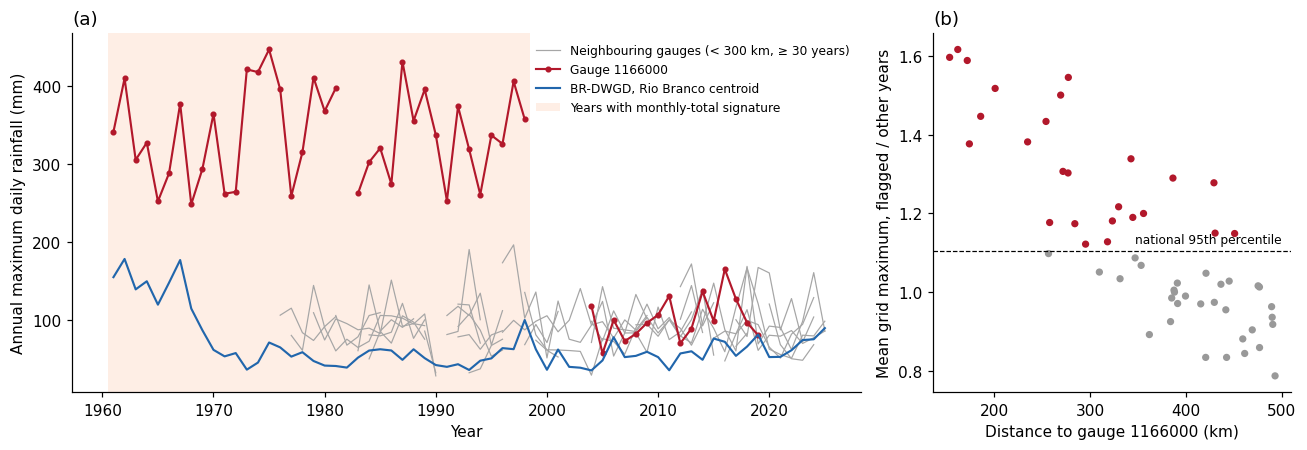

In [3]:
afetados = influencia[influencia.afetado]
fig = plt.figure(figsize=(12, 4.2))
ax1 = fig.add_subplot(1, 3, (1, 2))
for sid in viz.id.head(6):
    ax1.plot(est_max.index, est_max[sid], color='0.65', lw=0.8)
ax1.plot([], [], color='0.65', lw=0.8, label='Neighbouring gauges (< 300 km, ≥ 30 years)')
ax1.plot(est_max.index, est_max[s['id']], color='#b2182b', lw=1.4, marker='o', ms=3, label=f"Gauge {s['id']}")
rb = grade['1200401']
ax1.plot(rb.index, rb, color='#2166ac', lw=1.4, label='BR-DWGD, Rio Branco centroid')
ax1.axvspan(ruins[0] - 0.5, ruins[-1] + 0.5, color='#fddbc7', alpha=0.45, lw=0, label='Years with monthly-total signature')
ax1.set_xlabel('Year'); ax1.set_ylabel('Annual maximum daily rainfall (mm)')
ax1.legend(fontsize=8, frameon=False, loc='upper right'); ax1.set_title('(a)', loc='left')

ax2 = fig.add_subplot(1, 3, 3)
ax2.scatter(influencia.dist_km, influencia.razao, s=14, c=np.where(influencia.afetado, '#b2182b', '0.6'))
ax2.axhline(influencia.limiar_p95.iloc[0], color='k', ls='--', lw=0.8)
ax2.text(500, influencia.limiar_p95.iloc[0] + 0.02, 'national 95th percentile', ha='right', fontsize=8)
ax2.set_xlabel(f"Distance to gauge {s['id']} (km)")
ax2.set_ylabel('Mean grid maximum, flagged / other years')
ax2.set_title('(b)', loc='left')
plt.tight_layout()
plt.savefig(FIG / 'qc_estacao_1166000.png', dpi=300, bbox_inches='tight')
plt.show()

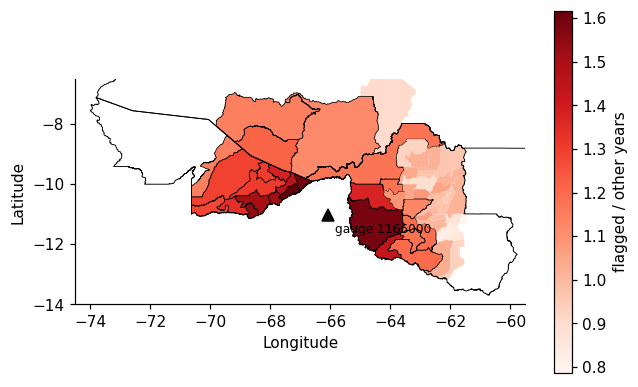

uf
AC    13
AM     3
RO     9
dtype: int64

In [4]:
m = municipios_gdf.merge(influencia[['codigo_ibge', 'razao', 'afetado']], on='codigo_ibge', how='inner')
fig, ax = plt.subplots(figsize=(6, 5))
estados_gdf[estados_gdf.abbrev_state.isin(['AC', 'RO', 'AM'])].boundary.plot(ax=ax, color='k', lw=0.6)
m.plot(column='razao', cmap='Reds', ax=ax, legend=True, legend_kwds={'label': 'flagged / other years', 'shrink': 0.7},
       edgecolor=np.where(m.afetado, 'k', 'none'), linewidth=0.5)
ax.plot(s['lon'], s['lat'], marker='^', color='k', ms=8)
ax.annotate(f"gauge {s['id']}", (s['lon'], s['lat']), xytext=(5, -12), textcoords='offset points', fontsize=8)
ax.set_xlim(-74.5, -59.5); ax.set_ylim(-14, -6.5); ax.set_aspect('equal')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout(); plt.savefig(FIG / 'qc_mapa_municipios_afetados.png', dpi=300, bbox_inches='tight'); plt.show()
afetados.groupby('uf').size()

## 2. Effect of the exclusion on the IDF coefficients

The 25 affected municipalities are refitted with and without the flagged years, using the same functions as `calcular_idf_municipios.py`.

In [5]:
linhas = []
for codigo, info in qc['municipios'].items():
    x = grade[codigo].dropna()
    for rotulo, serie_x in [('completa', x), ('qc', x.drop(info['anos']))]:
        esc = idf.escolher_distribuicao(serie_x.values)
        cal = idf.calibrar_equacao_idf(idf.quantis_por_duracao(esc['dist'], esc['params']))
        linhas.append({'codigo_ibge': codigo, 'nome': info['nome'], 'uf': info['uf'], 'serie': rotulo,
                       'n_anos': len(serie_x), 'distribuicao': esc['nome'], 'k': cal['k'], 'a': cal['a'],
                       'media_mm': serie_x.mean(), 'cv': serie_x.std() / serie_x.mean()})
efeito = pd.DataFrame(linhas).pivot(index=['codigo_ibge', 'nome', 'uf'], columns='serie',
                                    values=['n_anos', 'distribuicao', 'a', 'k', 'media_mm', 'cv'])
efeito[('psi100_5', 'completa')] = 20 ** efeito[('a', 'completa')].astype(float)
efeito[('psi100_5', 'qc')] = 20 ** efeito[('a', 'qc')].astype(float)
efeito.to_csv(QC / 'efeito_exclusao_coeficientes.csv')
efeito.sort_index(level='uf').round(3)

n_anos     distribuicao           \
serie                                  completa  qc     completa       qc   
codigo_ibge nome                    uf                                      
1200013     Acrelândia              AC       65  28          GEV   Normal   
1200054     Assis Brasil            AC       65  27          GEV      GEV   
1200104     Brasiléia               AC       65  28          GEV      GEV   
1200138     Bujari                  AC       65  28          GEV  Weibull   
1200179     Capixaba                AC       65  28          GEV  Weibull   
...                                         ...  ..          ...      ...   
3553401     Tanabi                  SP       65  64      Weibull  Weibull   
3554508     Tietê                   SP       65  64          GEV  Weibull   
1700707     Alvorada                TO       65  64          GEV      GEV   
1707009     Dianópolis              TO       65  64   Log-Normal   Gumbel   
1717909     Ponte Alta do Tocantins TO       65  64       Gumbel      GEV   

                                               a                     k  \
serie                                   completa        qc    completa   
codigo_ibge nome                    uf                                   
1200013     Acrelândia              AC  0.445088  0.078882  532.603271   
1200054     Assis Brasil            AC  0.533424  0.243298  349.331311   
1200104     Brasiléia               AC  0.495601  0.294395  393.990736   
1200138     Bujari                  AC   0.36367  0.081962   510.07571   
1200179     Capixaba                AC  0.434736  0.166341  518.549135   
...                                          ...       ...         ...   
3553401     Tanabi                  SP  0.168685  0.153072  795.604981   
3554508     Tietê                   SP  0.195515  0.144384  626.602962   
1700707     Alvorada                TO  0.191973  0.177096   520.75587   
1707009     Dianópolis              TO  0.166535  0.145825  606.175659   
1717909     Ponte Alta do Tocantins TO  0.142565  0.116949  566.852982   

                                                     media_mm             \
serie                                           qc   completa         qc   
codigo_ibge nome                    uf                                     
1200013     Acrelândia              AC  704.389614  74.488623  55.589443   
1200054     Assis Brasil            AC  475.675116  61.798718  51.003413   
1200104     Brasiléia               AC  459.037512  63.620602  53.322955   
1200138     Bujari                  AC  690.613075  63.853963  54.470668   
1200179     Capixaba                AC   614.15761  71.469722  55.203193   
...                                            ...        ...        ...   
3553401     Tanabi                  SP   789.84666  68.546532  67.182266   
3554508     Tietê                   SP  685.818284  59.497754  58.376847   
1700707     Alvorada                TO   525.24571  49.823263  49.148271   
1707009     Dianópolis              TO  607.554409  53.747084  52.732131   
1717909     Ponte Alta do Tocantins TO  577.891364  49.210335  48.276419   

                                              cv           psi100_5         
serie                                   completa        qc completa     qc  
codigo_ibge nome                    uf                                      
1200013     Acrelândia              AC  0.541274  0.217618    3.794  1.267  
1200054     Assis Brasil            AC  0.566877  0.304055    4.943  2.073  
1200104     Brasiléia               AC  0.558597  0.321797    4.414  2.416  
1200138     Bujari                  AC  0.494406  0.222646    2.973  1.278  
1200179     Capixaba                AC  0.580179  0.294818    3.678  1.646  
...                                          ...       ...      ...    ...  
3553401     Tanabi                  SP  0.333627  0.300804    1.658  1.582  
3554508     Tietê                   SP  0.320958  0.290451    1.796  1.541  
1700707     A

In [6]:
ef = efeito.astype({c: float for c in efeito.columns if c[0] in ('a', 'k', 'media_mm', 'cv', 'psi100_5')})
for uf_, g in ef.groupby(level='uf'):
    print(f"{uf_}: a {g[('a','completa')].mean():.3f} -> {g[('a','qc')].mean():.3f};  "
          f"Psi100/5 {g[('psi100_5','completa')].mean():.2f} -> {g[('psi100_5','qc')].mean():.2f};  "
          f"média {g[('media_mm','completa')].mean():.1f} -> {g[('media_mm','qc')].mean():.1f} mm  (n={len(g)})")
rb = ef.xs('1200401', level='codigo_ibge')
print('Rio Branco:', rb[[('a','completa'), ('a','qc'), ('psi100_5','completa'), ('psi100_5','qc')]].round(3).to_dict('records'))

AC: a 0.428 -> 0.164;  Psi100/5 3.68 -> 1.66;  média 66.7 -> 54.0 mm  (n=13)
AM: a 0.253 -> 0.177;  Psi100/5 2.15 -> 1.72;  média 55.8 -> 51.1 mm  (n=3)
BA: a 0.178 -> 0.147;  Psi100/5 1.71 -> 1.56;  média 50.2 -> 49.2 mm  (n=7)
CE: a 0.158 -> 0.115;  Psi100/5 1.60 -> 1.41;  média 55.7 -> 54.2 mm  (n=1)
MG: a 0.143 -> 0.121;  Psi100/5 1.53 -> 1.44;  média 54.9 -> 53.9 mm  (n=9)
MT: a 0.169 -> 0.156;  Psi100/5 1.66 -> 1.60;  média 48.0 -> 47.2 mm  (n=2)
RO: a 0.217 -> 0.153;  Psi100/5 1.97 -> 1.61;  média 60.7 -> 54.6 mm  (n=19)
SP: a 0.166 -> 0.143;  Psi100/5 1.65 -> 1.54;  média 63.6 -> 62.4 mm  (n=4)
TO: a 0.167 -> 0.147;  Psi100/5 1.65 -> 1.56;  média 50.9 -> 50.1 mm  (n=3)
Rio Branco: [{('a', 'completa'): 0.372, ('a', 'qc'): 0.09, ('psi100_5', 'completa'): 3.052, ('psi100_5', 'qc'): 1.31}]


## 3. Grid vs. nearest gauge

Pares: 1400  (distância mediana 4.7 km, 48 anos em comum)
          razao         r
count  1400.000  1400.000
mean      0.731     0.535
std       0.088     0.169
min       0.421    -0.229
10%       0.612     0.308
25%       0.670     0.434
50%       0.735     0.552
75%       0.793     0.651
90%       0.839     0.743
max       1.130     0.930
Razão mediana por UF:
uf
RR    0.52
RO    0.52
PI    0.59
MT    0.59
TO    0.60
MS    0.63
PE    0.63
MA    0.64
PA    0.64
BA    0.65
RN    0.65
GO    0.65
AP    0.67
AL    0.68
PB    0.69
CE    0.70
RJ    0.71
DF    0.71
ES    0.72
MG    0.73
SE    0.74
SP    0.75
RS    0.80
PR    0.81
SC    0.82


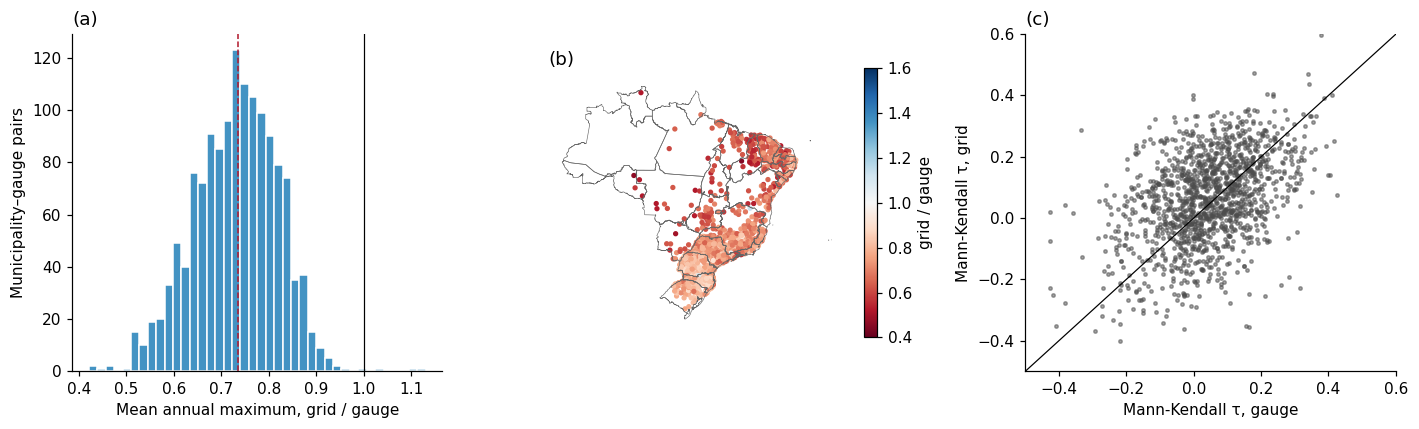

Tendência significativa (p<0,05): grade 21.6%, estação 14.8%, ambas e mesmo sinal 5.5%, só na grade 15.8%;  r(τ_grade, τ_estação) = 0.43
τ mediano: grade 0.070, estação 0.043


In [7]:
print(f'Pares: {len(pares)}  (distância mediana {pares.dist_km.median():.1f} km, {pares.n_anos.median():.0f} anos em comum)')
print(pares[['razao', 'r']].describe(percentiles=[.1, .25, .5, .75, .9]).round(3))
print('Razão mediana por UF:'); print(pares.groupby('uf').razao.median().round(2).sort_values().to_string())

fig, axs = plt.subplots(1, 3, figsize=(13, 4))
axs[0].hist(pares.razao, bins=40, color='#4393c3', edgecolor='white')
axs[0].axvline(1, color='k', lw=0.8); axs[0].axvline(pares.razao.median(), color='#b2182b', ls='--', lw=1)
axs[0].set_xlabel('Mean annual maximum, grid / gauge'); axs[0].set_ylabel('Municipality–gauge pairs'); axs[0].set_title('(a)', loc='left')

estados_gdf.boundary.plot(ax=axs[1], color='0.4', lw=0.4)
pm = pares.merge(est_meta[['id', 'lat', 'lon']], left_on='estacao', right_on='id')
sc = axs[1].scatter(pm.lon, pm.lat, c=pm.razao, cmap='RdBu', vmin=0.4, vmax=1.6, s=6)
plt.colorbar(sc, ax=axs[1], shrink=0.8, label='grid / gauge'); axs[1].set_aspect('equal'); axs[1].set_axis_off(); axs[1].set_title('(b)', loc='left')

axs[2].scatter(pares.tau_estacao, pares.tau_grade, s=5, alpha=0.5, color='0.3')
lim = [-0.5, 0.6]; axs[2].plot(lim, lim, color='k', lw=0.8)
axs[2].set_xlim(lim); axs[2].set_ylim(lim)
axs[2].set_xlabel("Mann-Kendall τ, gauge"); axs[2].set_ylabel("Mann-Kendall τ, grid"); axs[2].set_title('(c)', loc='left')
plt.tight_layout(); plt.savefig(FIG / 'qc_grade_vs_estacao.png', dpi=300, bbox_inches='tight'); plt.show()

sg, ss = pares.p_grade < .05, pares.p_estacao < .05
mesmo = np.sign(pares.tau_grade) == np.sign(pares.tau_estacao)
print(f'Tendência significativa (p<0,05): grade {sg.mean():.1%}, estação {ss.mean():.1%}, ambas e mesmo sinal {(sg & ss & mesmo).mean():.1%}, '
      f'só na grade {(sg & ~ss).mean():.1%};  r(τ_grade, τ_estação) = {pares.tau_grade.corr(pares.tau_estacao):.2f}')
print(f'τ mediano: grade {pares.tau_grade.median():.3f}, estação {pares.tau_estacao.median():.3f}')

## 4. Trends in the grid and changes in gauge density

Municípios: 5568;  MK p<0,05: 37.8%;  FDR(q=0,10): 1866 (1747 positivas, 119 negativas);  Pettitt FDR: 1492
                n  tau_mediano  pct_fdr_positivo
classe_rede                                     
strong loss  1085        0.098            27.097
loss         1085        0.057            18.618
stable        762        0.104            25.853
gain         1257        0.145            38.266
strong gain  1379        0.160            41.552
Spearman(Δ densidade, τ): SignificanceResult(statistic=0.21439781627936352, pvalue=6.637265328701744e-59)


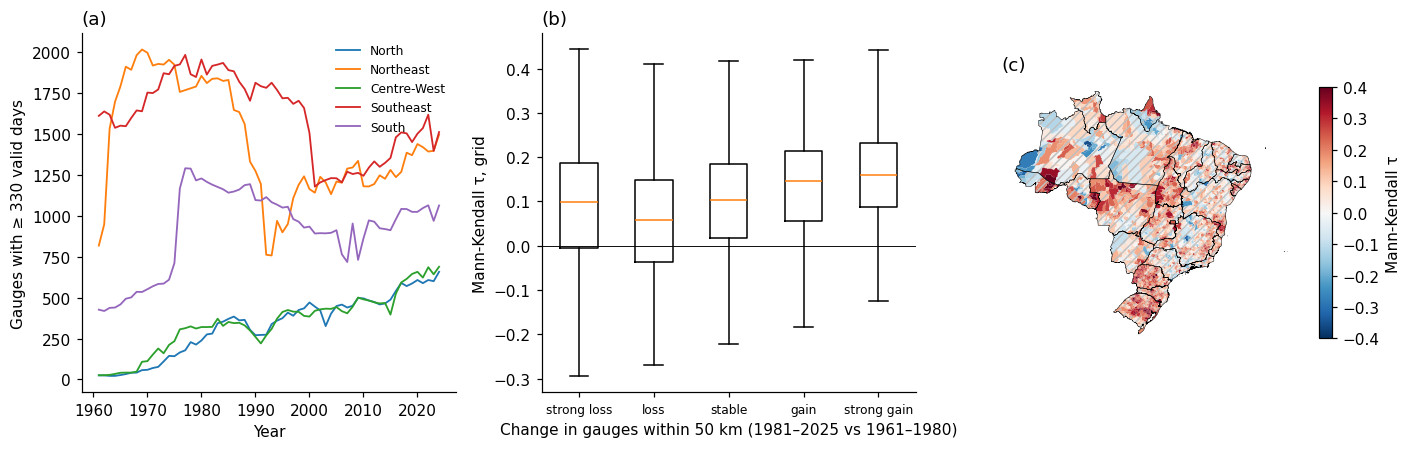

In [8]:
REGIAO = {'N': ['AC', 'AM', 'AP', 'PA', 'RO', 'RR', 'TO'], 'NE': ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'],
          'CO': ['DF', 'GO', 'MS', 'MT'], 'SE': ['ES', 'MG', 'RJ', 'SP'], 'S': ['PR', 'RS', 'SC']}
NOME_REGIAO = {'N': 'North', 'NE': 'Northeast', 'CO': 'Centre-West', 'SE': 'Southeast', 'S': 'South'}
por_regiao = pd.DataFrame({NOME_REGIAO[r]: contagem[[u for u in ufs if u in contagem]].sum(1) for r, ufs in REGIAO.items()})

tend['dlog_n50'] = np.log((tend.n50_1981_2025 + 0.5) / (tend.n50_1961_1980 + 0.5))
tend['classe_rede'] = pd.cut(tend.dlog_n50, [-9, -0.5, -0.1, 0.1, 0.5, 9],
                             labels=['strong loss', 'loss', 'stable', 'gain', 'strong gain'])
sig_pos = (tend.mk_fdr & (tend.mk_tau > 0)); sig_neg = (tend.mk_fdr & (tend.mk_tau < 0))
print(f'Municípios: {len(tend)};  MK p<0,05: {(tend.mk_p < .05).mean():.1%};  FDR(q=0,10): {tend.mk_fdr.sum()} '
      f'({sig_pos.sum()} positivas, {sig_neg.sum()} negativas);  Pettitt FDR: {tend.pettitt_fdr.sum()}')
resumo_rede = tend.groupby('classe_rede', observed=True).agg(n=('mk_tau', 'size'), tau_mediano=('mk_tau', 'median'),
                                                             pct_fdr_positivo=('mk_fdr', lambda v: (v & (tend.loc[v.index, 'mk_tau'] > 0)).mean() * 100))
print(resumo_rede.round(3))
from scipy import stats
print('Spearman(Δ densidade, τ):', stats.spearmanr(tend.dlog_n50, tend.mk_tau))

fig = plt.figure(figsize=(13, 4.2))
ax1 = fig.add_subplot(1, 3, 1)
por_regiao.loc[1961:2024].plot(ax=ax1, lw=1.2)  # 2025 still incomplete in the gauge file
ax1.set_xlabel('Year'); ax1.set_ylabel('Gauges with ≥ 330 valid days'); ax1.legend(fontsize=8, frameon=False); ax1.set_title('(a)', loc='left')
ax2 = fig.add_subplot(1, 3, 2)
grupos = [g.mk_tau.values for _, g in tend.groupby('classe_rede', observed=True)]
ax2.boxplot(grupos, labels=resumo_rede.index, showfliers=False)
ax2.axhline(0, color='k', lw=0.6); ax2.set_ylabel('Mann-Kendall τ, grid'); ax2.set_xlabel('Change in gauges within 50 km (1981–2025 vs 1961–1980)')
ax2.tick_params(axis='x', labelsize=8); ax2.set_title('(b)', loc='left')
ax3 = fig.add_subplot(1, 3, 3)
mm = municipios_gdf.merge(tend[['codigo_ibge', 'mk_tau', 'mk_fdr']], on='codigo_ibge')
mm.plot(column='mk_tau', cmap='RdBu_r', vmin=-0.4, vmax=0.4, ax=ax3, linewidth=0, legend=True,
        legend_kwds={'label': 'Mann-Kendall τ', 'shrink': 0.7})
mm[~mm.mk_fdr].plot(ax=ax3, facecolor='none', hatch='////', edgecolor='0.75', linewidth=0)
estados_gdf.boundary.plot(ax=ax3, color='k', lw=0.3); ax3.set_axis_off(); ax3.set_title('(c)', loc='left')
plt.tight_layout(); plt.savefig(FIG / 'qc_tendencias_rede.png', dpi=300, bbox_inches='tight'); plt.show()

In [9]:
uf_tab = tend.groupby('uf').agg(n=('mk_tau', 'size'), pct_fdr=('mk_fdr', 'mean'), tau_mediano=('mk_tau', 'median'),
                                n50_6180=('n50_1961_1980', 'mean'), n50_8125=('n50_1981_2025', 'mean'))
uf_tab['pct_fdr'] *= 100
v = pd.DataFrame({'1961-1980': contagem.loc[1961:1980].mean(), '1981-2025': contagem.loc[1981:2025].mean()})
uf_tab = uf_tab.join(v)
uf_tab.round(2).sort_values('pct_fdr', ascending=False)

,n,pct_fdr,tau_mediano,n50_6180,n50_8125,1961-1980,1981-2025
uf,,,,,,,
DF,1,100.00,0.25,10.25,33.33,6.50,18.47
RS,497,65.39,0.22,9.66,7.07,235.45,212.09
PR,399,64.16,0.21,13.20,24.08,352.05,638.67
SE,75,53.33,0.20,20.88,7.02,65.10,18.09
PB,223,52.47,0.19,16.61,22.28,111.55,170.36
TO,139,44.60,0.17,0.87,2.21,27.20,78.49
AL,102,44.12,0.16,16.04,7.43,62.25,31.07
AP,16,43.75,-0.09,0.27,1.07,4.30,19.00
AC,22,40.91,0.21,0.09,1.03,3.05,21.69


## 5. Numbers for the paper

In [10]:
from exportar_dados_site import corrigir_uf
idf_reg = json.load(open(BASE / 'idf_municipios.json', encoding='utf-8'))
dfi = pd.DataFrame([{'codigo_ibge': r['codigo_ibge'], 'uf': corrigir_uf(r['codigo_ibge'], r['uf']), 'a': r['idf']['a'],
                     'k': r['idf']['k'], 'n_anos': r['n_anos']} for r in idf_reg])
print('Municípios com curva IDF:', len(dfi), '| com série reduzida pelo QC:', (dfi.n_anos < 65).sum(),
      '| anos mínimos:', dfi.n_anos.min())
print('a médio por UF (top 6):'); print(dfi.groupby('uf').a.agg(['mean', 'std']).sort_values('mean', ascending=False).head(6).round(3))
print(f"Grade/estação: razão mediana {pares.razao.median():.2f} (IQR {pares.razao.quantile(.25):.2f}–{pares.razao.quantile(.75):.2f}), "
      f"r mediano {pares.r.median():.2f}")

Municípios com curva IDF: 5569 | com série reduzida pelo QC: 61 | anos mínimos: 27
a médio por UF (top 6):
     mean    std
uf              
PE  0.184  0.047
RN  0.181  0.048
SE  0.175  0.020
RJ  0.172  0.050
PB  0.169  0.034
AL  0.168  0.029
Grade/estação: razão mediana 0.74 (IQR 0.67–0.79), r mediano 0.55
